<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_14B_DenseNet121_Grad_CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 14B — Grad-CAM Explainability for the Final DenseNet121 Model

## Purpose

Following cross-architecture comparison using validation PR-AUC, the
fine-tuned DenseNet121 model was selected as the final architecture.

This notebook performs Grad-CAM explainability analysis on the selected
DenseNet121 model using the untouched test set.

The objectives are to:

1. Load the selected fine-tuned DenseNet121 checkpoint.
2. Reconstruct the same test dataset used during model evaluation.
3. Verify that test predictions reproduce the previously reported metrics.
4. Identify the final convolutional feature layer automatically.
5. Generate class-targeted Grad-CAM explanations.
6. Categorise test predictions into TP, TN, FP and FN.
7. Generate high-confidence and typical examples.
8. Save Grad-CAM images and metadata for dissertation reporting.
9. Preserve deployment-ready explainability artifacts.

Important methodological note:
Architecture selection was performed using validation PR-AUC. Test-set
performance is used only for final evaluation and explainability analysis.

##2. Imports

In [114]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd

import tensorflow as tf

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from PIL import Image

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


##3. mount Google Drive safely

In [115]:
from google.colab import drive

MOUNT_POINT = "/content/drive"

if os.path.ismount(MOUNT_POINT):
    print("Google Drive is already mounted.")
else:
    drive.mount(MOUNT_POINT)

Google Drive is already mounted.


##4. Project Paths

##5. Load and verify corrected final selction

In [116]:
FINAL_SELECTION_PATH = (
    COMPARISON_ROOT
    / "final_model_selection.json"
)

with open(
    FINAL_SELECTION_PATH,
    "r"
) as file:

    final_selection = json.load(file)

print(
    json.dumps(
        final_selection,
        indent=4
    )
)

{
    "FinalArchitecture": "DenseNet121",
    "SelectedConfiguration": "Fine-Tuned DenseNet121",
    "PrimarySelectionMetric": "Validation PR-AUC",
    "ValidationROCAUC": 0.8615857826384143,
    "ValidationPRAUC": 0.5876770576684937,
    "TestROCAUC": 0.855332902391726,
    "TestPRAUC": 0.5881362975400494
}


In [117]:
assert (
    final_selection["FinalArchitecture"]
    == "DenseNet121"
), (
    "Notebook 14B expects DenseNet121 to be "
    "the validation-selected final architecture."
)

print(
    "Final architecture confirmed:",
    final_selection["FinalArchitecture"]
)

Final architecture confirmed: DenseNet121


##6. Load DenseNet121 summary

In [118]:
DENSENET_SUMMARY_PATH = (
    DENSENET_RESULTS_ROOT
    / "densenet121_experiment_summary.csv"
)

densenet_summary = pd.read_csv(
    DENSENET_SUMMARY_PATH
)

display(
    densenet_summary
)

,Selected Model,Baseline Validation ROC-AUC,Baseline Validation PR-AUC,Fine-Tuned Validation ROC-AUC,Fine-Tuned Validation PR-AUC,Validation F1 Threshold,Validation High-Recall Threshold,Test ROC-AUC,Test PR-AUC
0,Fine-Tuned DenseNet121,0.814935,0.489087,0.861586,0.587677,0.669041,0.445648,0.855333,0.588136


In [119]:
F1_THRESHOLD = float(
    densenet_summary.loc[
        0,
        "Validation F1 Threshold"
    ]
)

HIGH_RECALL_THRESHOLD = float(
    densenet_summary.loc[
        0,
        "Validation High-Recall Threshold"
    ]
)

EXPECTED_TEST_ROC_AUC = float(
    densenet_summary.loc[
        0,
        "Test ROC-AUC"
    ]
)

EXPECTED_TEST_PR_AUC = float(
    densenet_summary.loc[
        0,
        "Test PR-AUC"
    ]
)

print(
    "Validation F1 threshold:",
    F1_THRESHOLD
)

print(
    "High-recall threshold:",
    HIGH_RECALL_THRESHOLD
)

print(
    "Expected test ROC-AUC:",
    EXPECTED_TEST_ROC_AUC
)

print(
    "Expected test PR-AUC:",
    EXPECTED_TEST_PR_AUC
)

Validation F1 threshold: 0.6690409183502197
High-recall threshold: 0.4456476867198944
Expected test ROC-AUC: 0.855332902391726
Expected test PR-AUC: 0.5881362975400494


##7. Recreate the DenseNet preprocessing layer

In [120]:
@tf.keras.utils.register_keras_serializable(
    package="LungNoduleClassification"
)
class DenseNetPreprocessing(
    tf.keras.layers.Layer
):

    def call(
        self,
        inputs
    ):

        return (
            tf.keras.applications
            .densenet
            .preprocess_input(
                inputs
            )
        )

    def get_config(self):

        return super().get_config()

##8. Load the selected DenseNet model

In [121]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "Models"
)

DENSENET_ROOT = (
    MODEL_ROOT
    / "DenseNet121"
    / "Corrected_Run_01"
)

DENSENET_FINE_TUNE_ROOT = (
    DENSENET_ROOT
    / "FineTune_Last30"
)

MODEL_PATH = (
    DENSENET_FINE_TUNE_ROOT
    / "best_model.keras"
)

DENSENET_RESULTS_ROOT = (
    DENSENET_ROOT
    / "Results"
)

COMPARISON_ROOT = (
    MODEL_ROOT
    / "Model_Comparison"
)

GRADCAM_ROOT = (
    COMPARISON_ROOT
    / "GradCAM_DenseNet121"
)

GRADCAM_IMAGE_DIR = (
    GRADCAM_ROOT
    / "Images"
)

GRADCAM_OVERLAY_DIR = (
    GRADCAM_ROOT
    / "Overlays"
)

GRADCAM_HEATMAP_DIR = (
    GRADCAM_ROOT
    / "Heatmaps"
)

for path in [
    GRADCAM_ROOT,
    GRADCAM_IMAGE_DIR,
    GRADCAM_OVERLAY_DIR,
    GRADCAM_HEATMAP_DIR
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )

print("Model:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

print("Grad-CAM output:", GRADCAM_ROOT)

Model: /content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/best_model.keras
Model exists: True
Grad-CAM output: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_DenseNet121


In [122]:
densenet_model = (
    tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "DenseNetPreprocessing":
                DenseNetPreprocessing,

            "LungNoduleClassification>DenseNetPreprocessing":
                DenseNetPreprocessing
        },
        compile=False
    )
)

print(
    "Loaded model:",
    densenet_model.name
)

densenet_model.summary()

Loaded model: DenseNet121_LungNoduleClassifier


Model: "DenseNet121_LungNoduleClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_preprocessing          │ (None, 128, 128, 3)    │             0 │
│ (DenseNetPreprocessing)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 631,809 (2.41 MB)

 Non-trainable params: 6,406,720 (24.44 MB)

##9. Identify the DenseNet backbone

In [123]:
nested_models = [
    layer
    for layer in densenet_model.layers
    if isinstance(
        layer,
        tf.keras.Model
    )
]

print(
    "Nested models:"
)

for layer in nested_models:

    print(
        layer.name,
        type(layer).__name__
    )

Nested models:
data_augmentation Sequential
densenet121 Functional


In [124]:
densenet_candidates = [
    layer
    for layer in nested_models
    if "densenet" in layer.name.lower()
]

if len(densenet_candidates) != 1:

    raise RuntimeError(
        "Could not uniquely identify "
        "the DenseNet121 backbone."
    )

densenet_backbone = (
    densenet_candidates[0]
)

print(
    "DenseNet backbone:",
    densenet_backbone.name
)

DenseNet backbone: densenet121


##10. Identify the final convolutional layer

In [125]:
conv_layers = [
    layer
    for layer
    in densenet_backbone.layers

    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    )
]

print(
    "Number of Conv2D layers:",
    len(conv_layers)
)

print(
    "Last 10 Conv2D layers:"
)

for layer in conv_layers[-10:]:

    print(
        layer.name,
        layer.output.shape
    )

Number of Conv2D layers: 120
Last 10 Conv2D layers:
conv5_block12_1_conv (None, 4, 4, 128)
conv5_block12_2_conv (None, 4, 4, 32)
conv5_block13_1_conv (None, 4, 4, 128)
conv5_block13_2_conv (None, 4, 4, 32)
conv5_block14_1_conv (None, 4, 4, 128)
conv5_block14_2_conv (None, 4, 4, 32)
conv5_block15_1_conv (None, 4, 4, 128)
conv5_block15_2_conv (None, 4, 4, 32)
conv5_block16_1_conv (None, 4, 4, 128)
conv5_block16_2_conv (None, 4, 4, 32)


In [126]:
last_conv_layer = (
    conv_layers[-1]
)

LAST_CONV_LAYER_NAME = (
    last_conv_layer.name
)

print(
    "Selected Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

print(
    "Feature shape:",
    last_conv_layer.output.shape
)

Selected Grad-CAM layer: conv5_block16_2_conv
Feature shape: (None, 4, 4, 32)


##11. Create backbone feature extractor

In [127]:
# ============================================================
# DenseNet121 Grad-CAM Feature Extractor
# ============================================================

last_conv_layer = (
    densenet_backbone.get_layer(
        LAST_CONV_LAYER_NAME
    )
)

backbone_feature_extractor = tf.keras.Model(
    inputs=densenet_backbone.input,
    outputs=[
        last_conv_layer.output,
        densenet_backbone.output
    ],
    name="DenseNet121_GradCAM_FeatureExtractor"
)

print(
    "Feature extractor created successfully."
)

print(
    "Last convolution output shape:",
    backbone_feature_extractor.outputs[0].shape
)

print(
    "Backbone output shape:",
    backbone_feature_extractor.outputs[1].shape
)

Feature extractor created successfully.
Last convolution output shape: (None, 4, 4, 32)
Backbone output shape: (None, 4, 4, 1024)


##12. Find the test split file

In [128]:
SPLIT_ROOT = (
    PROJECT_ROOT
    / "Dataset"
    / "Processed"
)

TEST_SPLIT_PATH = (
    SPLIT_ROOT
    / "test.csv"
)

print(
    "Test split:",
    TEST_SPLIT_PATH
)

print(
    "Exists:",
    TEST_SPLIT_PATH.exists()
)

Test split: /content/drive/MyDrive/Dissertation/Dataset/Processed/test.csv
Exists: True


In [129]:
test_df = pd.read_csv(
    TEST_SPLIT_PATH
)

print(
    "Test samples:",
    len(test_df)
)

print(
    "\nClass distribution:"
)

print(
    test_df["CancerLabel"]
    .value_counts()
    .sort_index()
)

print(
    "\nPatients:",
    test_df["PatientID"]
    .nunique()
)

display(
    test_df.head()
)

Test samples: 256

Class distribution:
CancerLabel
0    221
1     35
Name: count, dtype: int64

Patients: 101


,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
0,LIDC-IDRI-0014,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
1,LIDC-IDRI-0018,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
2,LIDC-IDRI-0018,2,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
3,LIDC-IDRI-0018,3,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
4,LIDC-IDRI-0018,4,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...


##13. Resolve Colab image paths

In [130]:
CNN_DATASET_ROOT = (
    SPLIT_ROOT
    / "CNN_Dataset"
)

def resolve_image_path(row):

    label_name = (
        "Malignant"
        if int(row["CancerLabel"]) == 1
        else "Benign"
    )

    original_path = Path(
        str(row["ImagePath"])
    )

    filename = (
        original_path.name
    )

    resolved_path = (
        CNN_DATASET_ROOT
        / label_name
        / filename
    )

    return str(
        resolved_path
    )

In [131]:
test_df = (
    test_df.copy()
)

test_df[
    "ResolvedImagePath"
] = test_df.apply(
    resolve_image_path,
    axis=1
)

print("CNN_DATASET_ROOT", CNN_DATASET_ROOT)

CNN_DATASET_ROOT /content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset


In [132]:
test_df[
    "ImageExists"
] = (
    test_df[
        "ResolvedImagePath"
    ]
    .apply(
        lambda x:
            Path(x).exists()
    )
)

print(
    test_df[
        "ImageExists"
    ]
    .value_counts()
)

ImageExists
True    256
Name: count, dtype: int64


##14. Image Loader

In [133]:
IMAGE_SIZE = (
    128,
    128
)

In [134]:
def load_image_for_model(
    image_path
):

    image = (
        tf.io.read_file(
            image_path
        )
    )

    image = (
        tf.image.decode_png(
            image,
            channels=3
        )
    )

    image = (
        tf.image.resize(
            image,
            IMAGE_SIZE
        )
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image

##15. Build test dataset

In [135]:
AUTOTUNE = (
    tf.data.AUTOTUNE
)

BATCH_SIZE = 16

In [136]:
def build_test_dataset(
    dataframe
):

    paths = (
        dataframe[
            "ResolvedImagePath"
        ]
        .values
    )

    labels = (
        dataframe[
            "CancerLabel"
        ]
        .values
        .astype(
            np.int32
        )
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                paths,
                labels
            )
        )
    )

    dataset = dataset.map(
        lambda path, label:
        (
            load_image_for_model(
                path
            ),
            label
        ),
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [137]:
test_ds = build_test_dataset(
    test_df
)

print(
    test_ds.element_spec
)

(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


##16. Verify model predictions before Grad-CAM

In [138]:
test_probabilities = (
    densenet_model.predict(
        test_ds,
        verbose=1
    )
    .ravel()
)

test_true = (
    test_df[
        "CancerLabel"
    ]
    .astype(int)
    .values
)

#Calculate #

verified_test_roc_auc = (
    roc_auc_score(
        test_true,
        test_probabilities
    )
)

verified_test_pr_auc = (
    average_precision_score(
        test_true,
        test_probabilities
    )
)

print(
    "Verified test ROC-AUC:",
    verified_test_roc_auc
)

print(
    "Verified test PR-AUC:",
    verified_test_pr_auc
)

print(
    "\nExpected ROC-AUC:",
    EXPECTED_TEST_ROC_AUC
)

print(
    "Expected PR-AUC:",
    EXPECTED_TEST_PR_AUC
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
Verified test ROC-AUC: 0.855332902391726
Verified test PR-AUC: 0.5881362975400494

Expected ROC-AUC: 0.855332902391726
Expected PR-AUC: 0.5881362975400494


In [139]:
verified_test_roc_auc = (
    roc_auc_score(
        test_true,
        test_probabilities
    )
)

verified_test_pr_auc = (
    average_precision_score(
        test_true,
        test_probabilities
    )
)

print(
    "Verified test ROC-AUC:",
    verified_test_roc_auc
)

print(
    "Verified test PR-AUC:",
    verified_test_pr_auc
)

print(
    "\nExpected ROC-AUC:",
    EXPECTED_TEST_ROC_AUC
)

print(
    "Expected PR-AUC:",
    EXPECTED_TEST_PR_AUC
)

Verified test ROC-AUC: 0.855332902391726
Verified test PR-AUC: 0.5881362975400494

Expected ROC-AUC: 0.855332902391726
Expected PR-AUC: 0.5881362975400494


##17. Apply validation-selected F1 threshold

In [140]:
test_predicted = (
    test_probabilities
    >= F1_THRESHOLD
).astype(int)

gradcam_test_df = (
    test_df.copy()
)

gradcam_test_df[
    "PredictedProbability"
] = test_probabilities

gradcam_test_df[
    "PredictedLabel"
] = test_predicted

##18. Classify TP/TN/FP/FN

In [141]:
def prediction_outcome(
    true_label,
    predicted_label
):

    if (
        true_label == 1
        and predicted_label == 1
    ):
        return "TP"

    if (
        true_label == 0
        and predicted_label == 0
    ):
        return "TN"

    if (
        true_label == 0
        and predicted_label == 1
    ):
        return "FP"

    if (
        true_label == 1
        and predicted_label == 0
    ):
        return "FN"

    return "Unknown"

In [142]:
gradcam_test_df[
    "Outcome"
] = [
    prediction_outcome(
        int(true_label),
        int(predicted_label)
    )

    for true_label, predicted_label
    in zip(
        gradcam_test_df[
            "CancerLabel"
        ],

        gradcam_test_df[
            "PredictedLabel"
        ]
    )
]


print(
    gradcam_test_df[
        "Outcome"
    ]
    .value_counts()
)

Outcome
TN    214
FN     20
TP     15
FP      7
Name: count, dtype: int64


##19. Final confusion matrix verification

In [143]:
cm = confusion_matrix(
    test_true,
    test_predicted
)

print(
    cm
)

print()

print(
    classification_report(
        test_true,
        test_predicted,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

[[214   7]
 [ 20  15]]

              precision    recall  f1-score   support

      Benign     0.9145    0.9683    0.9407       221
   Malignant     0.6818    0.4286    0.5263        35

    accuracy                         0.8945       256
   macro avg     0.7982    0.6984    0.7335       256
weighted avg     0.8827    0.8945    0.8840       256



##20. build class-targeted Grad-CAM function

In [144]:
# ============================================================
# Class-Targeted Grad-CAM for Nested DenseNet121
# ============================================================

def make_gradcam_heatmap(
    image_batch,
    model,
    backbone,
    feature_extractor,
    target_class
):

    image_batch = tf.cast(
        image_batch,
        tf.float32
    )

    # Find DenseNet backbone position
    backbone_index = (
        model.layers.index(
            backbone
        )
    )

    with tf.GradientTape() as tape:

        # ----------------------------------------------------
        # 1. Pass through OUTER layers before DenseNet121
        # ----------------------------------------------------

        x = image_batch

        for layer in model.layers[
            1:backbone_index
        ]:

            try:
                x = layer(
                    x,
                    training=False
                )

            except TypeError:
                x = layer(x)

        # ----------------------------------------------------
        # 2. Run DenseNet graph normally
        #
        # We retrieve:
        # - final convolution feature map
        # - final backbone output
        #
        # DO NOT manually replay DenseNet internal layers.
        # ----------------------------------------------------

        conv_outputs, backbone_output = (
            feature_extractor(
                x,
                training=False
            )
        )

        # ----------------------------------------------------
        # 3. Continue through OUTER classifier head
        # ----------------------------------------------------

        y = backbone_output

        for layer in model.layers[
            backbone_index + 1:
        ]:

            try:
                y = layer(
                    y,
                    training=False
                )

            except TypeError:
                y = layer(y)

        # Binary sigmoid output
        malignant_probability = (
            y[:, 0]
        )

        # ----------------------------------------------------
        # 4. Select class being explained
        # ----------------------------------------------------

        if target_class == 1:

            # Explain malignant prediction
            target_score = (
                malignant_probability
            )

        elif target_class == 0:

            # Explain benign prediction
            target_score = (
                1.0
                - malignant_probability
            )

        else:

            raise ValueError(
                "target_class must be "
                "0 (Benign) or 1 (Malignant)."
            )

    # --------------------------------------------------------
    # 5. Gradients of class score w.r.t convolution features
    # --------------------------------------------------------

    gradients = tape.gradient(
        target_score,
        conv_outputs
    )

    if gradients is None:

        raise RuntimeError(
            "Gradients are None. "
            "Check Grad-CAM model connectivity."
        )

    # --------------------------------------------------------
    # 6. Global-average-pool gradients
    # --------------------------------------------------------

    pooled_gradients = (
        tf.reduce_mean(
            gradients,
            axis=(0, 1, 2)
        )
    )

    # Remove batch dimension
    conv_outputs = (
        conv_outputs[0]
    )

    # --------------------------------------------------------
    # 7. Weighted feature map combination
    # --------------------------------------------------------

    heatmap = tf.reduce_sum(
        conv_outputs
        * pooled_gradients,
        axis=-1
    )

    # Standard Grad-CAM ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # --------------------------------------------------------
    # 8. Normalize heatmap to [0, 1]
    # --------------------------------------------------------

    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()

##21. Test Grad-CAM on one sample

In [145]:
sample_row = (
    gradcam_test_df
    .iloc[0]
)

sample_image = (
    load_image_for_model(
        sample_row[
            "ResolvedImagePath"
        ]
    )
)

sample_batch = (
    tf.expand_dims(
        sample_image,
        axis=0
    )
)

sample_target_class = int(
    sample_row[
        "PredictedLabel"
    ]
)

In [146]:
sample_heatmap = (
    make_gradcam_heatmap(
        image_batch=sample_batch,
        model=densenet_model,
        backbone=densenet_backbone,
        feature_extractor=backbone_feature_extractor,
        target_class=sample_target_class
    )
)

print(
    "Heatmap shape:",
    sample_heatmap.shape
)

print(
    "Minimum:",
    sample_heatmap.min()
)

print(
    "Maximum:",
    sample_heatmap.max()
)

Heatmap shape: (4, 4)
Minimum: 0.0
Maximum: 1.0


In [147]:
# ============================================================
# Validate Grad-CAM Output
# ============================================================

assert (
    sample_heatmap.ndim == 2
), (
    "Grad-CAM heatmap must be 2-dimensional."
)

assert (
    np.isfinite(
        sample_heatmap
    ).all()
), (
    "Grad-CAM contains NaN or infinite values."
)

assert (
    sample_heatmap.min()
    >= 0
), (
    "Grad-CAM contains negative values."
)

assert (
    sample_heatmap.max()
    <= 1.0001
), (
    "Grad-CAM was not normalized correctly."
)

print(
    "✓ DenseNet121 Grad-CAM heatmap "
    "validated successfully."
)

✓ DenseNet121 Grad-CAM heatmap validated successfully.


##22. Overlay function

In [148]:
def create_gradcam_overlay(
    image,
    heatmap,
    alpha=0.40
):

    image_np = (
        image.numpy()
        if tf.is_tensor(image)
        else np.asarray(image)
    )

    image_np = np.clip(
        image_np,
        0,
        255
    ).astype(
        np.uint8
    )

    heatmap_resized = (
        tf.image.resize(
            heatmap[..., np.newaxis],
            IMAGE_SIZE
        )
        .numpy()
        .squeeze()
    )

    heatmap_uint8 = np.uint8(
        255
        * heatmap_resized
    )

    colormap = (
        plt.get_cmap(
            "jet"
        )
    )

    heatmap_rgb = (
        colormap(
            heatmap_uint8
        )[
            ...,
            :3
        ]
        * 255
    ).astype(
        np.uint8
    )

    overlay = (
        image_np
        * (1 - alpha)
        +
        heatmap_rgb
        * alpha
    )

    overlay = np.clip(
        overlay,
        0,
        255
    ).astype(
        np.uint8
    )

    return (
        heatmap_resized,
        heatmap_rgb,
        overlay
    )

##23. Visual sanity check

In [149]:
heatmap_resized, \
heatmap_rgb, \
sample_overlay = (
    create_gradcam_overlay(
        sample_image,
        sample_heatmap
    )
)

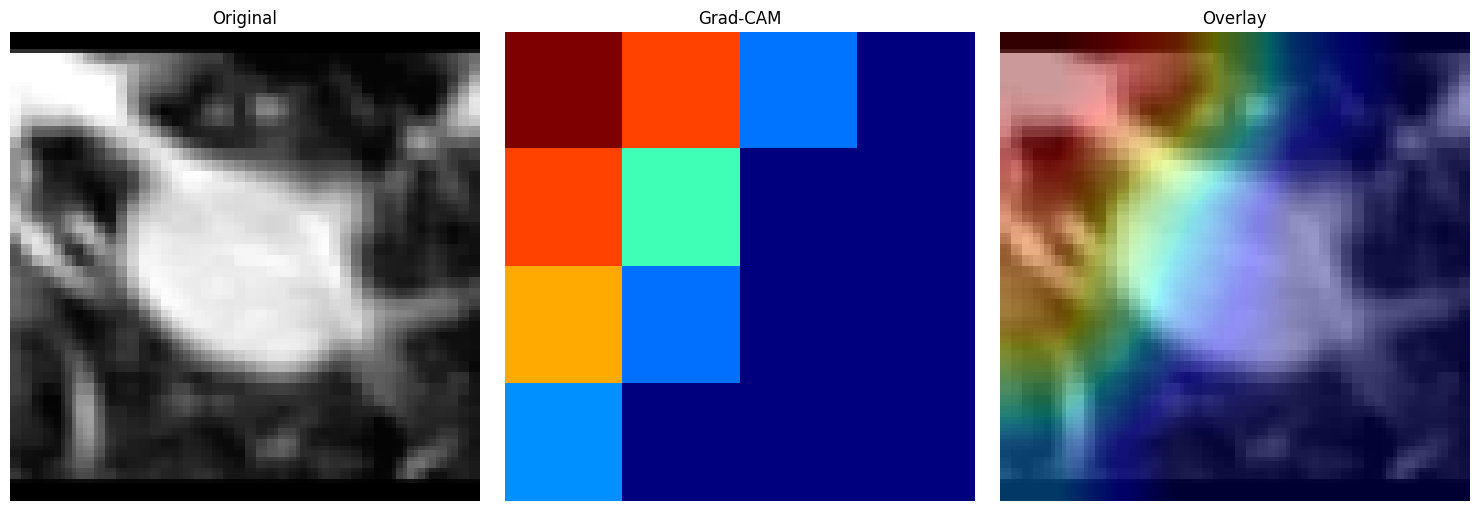

In [150]:
plt.figure(
    figsize=(15, 5)
)

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    sample_image.numpy()
    .astype(np.uint8)
)

plt.title(
    "Original"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    sample_heatmap,
    cmap="jet"
)

plt.title(
    "Grad-CAM"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    sample_overlay
)

plt.title(
    "Overlay"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()

##24. Seelct high-confidence examples

In [151]:
high_confidence_cases = []

selection_rules = {
    "TP": False,
    "FP": False,
    "TN": True,
    "FN": True
}

for outcome, ascending in (
    selection_rules.items()
):

    subset = (
        gradcam_test_df[
            gradcam_test_df[
                "Outcome"
            ] == outcome
        ]
        .sort_values(
            "PredictedProbability",
            ascending=ascending
        )
        .head(3)
    )

    high_confidence_cases.append(
        subset
    )

high_confidence_df = (
    pd.concat(
        high_confidence_cases,
        ignore_index=True
    )
)

In [152]:
display(
    high_confidence_df[
        [
            "PatientID",
            "NoduleID",
            "CancerLabel",
            "PredictedProbability",
            "PredictedLabel",
            "Outcome"
        ]
    ]
)

,PatientID,NoduleID,CancerLabel,PredictedProbability,PredictedLabel,Outcome
0,LIDC-IDRI-0385,2,1,0.992176,1,TP
1,LIDC-IDRI-0203,2,1,0.981403,1,TP
2,LIDC-IDRI-0265,1,1,0.968206,1,TP
3,LIDC-IDRI-0750,3,0,0.942304,1,FP
4,LIDC-IDRI-0439,2,0,0.931524,1,FP
5,LIDC-IDRI-0315,4,0,0.860312,1,FP
6,LIDC-IDRI-0358,1,0,0.011102,0,TN
7,LIDC-IDRI-0870,2,0,0.013683,0,TN
8,LIDC-IDRI-0160,4,0,0.015772,0,TN
9,LIDC-IDRI-0195,7,1,0.057864,0,FN


##25. Select typical examples

In [153]:
typical_cases = []

outcome_order = [
    "TP",
    "TN",
    "FP",
    "FN"
]

In [154]:
for outcome in outcome_order:

    subset = (
        gradcam_test_df[
            gradcam_test_df[
                "Outcome"
            ] == outcome
        ]
        .copy()
    )

    if len(subset) == 0:
        continue

    median_probability = (
        subset[
            "PredictedProbability"
        ]
        .median()
    )

    subset[
        "DistanceFromMedian"
    ] = np.abs(
        subset[
            "PredictedProbability"
        ]
        - median_probability
    )

    typical_cases.append(
        subset.sort_values(
            "DistanceFromMedian"
        )
        .iloc[0]
    )

In [155]:
typical_cases_df = (
    pd.DataFrame(
        typical_cases
    )
)

In [156]:
display(
    typical_cases_df[
        [
            "PatientID",
            "NoduleID",
            "CancerLabel",
            "PredictedProbability",
            "PredictedLabel",
            "Outcome"
        ]
    ]
)

,PatientID,NoduleID,CancerLabel,PredictedProbability,PredictedLabel,Outcome
4,LIDC-IDRI-0018,4,1,0.867159,1,TP
194,LIDC-IDRI-0565,2,0,0.134239,0,TN
92,LIDC-IDRI-0315,7,0,0.841051,1,FP
72,LIDC-IDRI-0229,4,1,0.353470,0,FN


##26. Save individual Grad-CAM examples

In [157]:
gradcam_metadata = []

for index, row in (
    high_confidence_df
    .iterrows()
):

    image = (
        load_image_for_model(
            row[
                "ResolvedImagePath"
            ]
        )
    )

    image_batch = (
        tf.expand_dims(
            image,
            axis=0
        )
    )

    predicted_label = int(
        row[
            "PredictedLabel"
        ]
    )

    heatmap = (
        make_gradcam_heatmap(
            image_batch=image_batch,
            model=densenet_model,
            backbone=densenet_backbone,
            feature_extractor=backbone_feature_extractor,
            target_class=predicted_label
        )
    )

    heatmap_resized, \
    heatmap_rgb, \
    overlay = (
        create_gradcam_overlay(
            image,
            heatmap
        )
    )

    patient_id = str(
        row[
            "PatientID"
        ]
    )

    nodule_id = str(
        row[
            "NoduleID"
        ]
    )

    outcome = str(
        row[
            "Outcome"
        ]
    )

    base_name = (
        f"{outcome}_"
        f"{patient_id}_"
        f"Nodule_{nodule_id}"
    )

    overlay_path = (
        GRADCAM_OVERLAY_DIR
        / f"{base_name}_overlay.png"
    )

    heatmap_path = (
        GRADCAM_HEATMAP_DIR
        / f"{base_name}_heatmap.png"
    )

    Image.fromarray(
        overlay
    ).save(
        overlay_path
    )

    Image.fromarray(
        heatmap_rgb
    ).save(
        heatmap_path
    )

    gradcam_metadata.append(
        {
            "PatientID":
                patient_id,

            "NoduleID":
                nodule_id,

            "TrueLabel":
                int(
                    row[
                        "CancerLabel"
                    ]
                ),

            "PredictedLabel":
                predicted_label,

            "PredictedProbability":
                float(
                    row[
                        "PredictedProbability"
                    ]
                ),

            "Outcome":
                outcome,

            "ExplainedClass":
                (
                    "Malignant"
                    if predicted_label == 1
                    else "Benign"
                ),

            "GradCAMLayer":
                LAST_CONV_LAYER_NAME,

            "HeatmapHeight":
                int(
                    heatmap.shape[0]
                ),

            "HeatmapWidth":
                int(
                    heatmap.shape[1]
                ),

            "OverlayPath":
                str(
                    overlay_path
                ),

            "HeatmapPath":
                str(
                    heatmap_path
                )
        }
    )

##27. Save metadata

In [158]:
gradcam_metadata_df = (
    pd.DataFrame(
        gradcam_metadata
    )
)

GRADCAM_METADATA_PATH = (
    GRADCAM_ROOT
    / "gradcam_metadata.csv"
)

gradcam_metadata_df.to_csv(
    GRADCAM_METADATA_PATH,
    index=False
)

print(
    "Saved:",
    GRADCAM_METADATA_PATH
)

display(
    gradcam_metadata_df
)

Saved: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_DenseNet121/gradcam_metadata.csv


,PatientID,NoduleID,TrueLabel,PredictedLabel,PredictedProbability,Outcome,ExplainedClass,GradCAMLayer,HeatmapHeight,HeatmapWidth,OverlayPath,HeatmapPath
0,LIDC-IDRI-0385,2,1,1,0.992176,TP,Malignant,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
1,LIDC-IDRI-0203,2,1,1,0.981403,TP,Malignant,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
2,LIDC-IDRI-0265,1,1,1,0.968206,TP,Malignant,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
3,LIDC-IDRI-0750,3,0,1,0.942304,FP,Malignant,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
4,LIDC-IDRI-0439,2,0,1,0.931524,FP,Malignant,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
5,LIDC-IDRI-0315,4,0,1,0.860312,FP,Malignant,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
6,LIDC-IDRI-0358,1,0,0,0.011102,TN,Benign,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
7,LIDC-IDRI-0870,2,0,0,0.013683,TN,Benign,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
8,LIDC-IDRI-0160,4,0,0,0.015772,TN,Benign,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...
9,LIDC-IDRI-0195,7,1,0,0.057864,FN,Benign,conv5_block16_2_conv,4,4,/content/drive/MyDrive/Dissertation/Models/Mod...,/content/drive/MyDrive/Dissertation/Models/Mod...


##28. Save complete test predictions

In [159]:
DENSENET_TEST_PREDICTIONS_PATH = (
    GRADCAM_ROOT
    / "densenet121_test_predictions.csv"
)

gradcam_test_df.to_csv(
    DENSENET_TEST_PREDICTIONS_PATH,
    index=False
)

print(
    "Saved:",
    DENSENET_TEST_PREDICTIONS_PATH
)

Saved: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_DenseNet121/densenet121_test_predictions.csv


##29. Save outcome summary

In [160]:
outcome_summary = (
    gradcam_test_df[
        "Outcome"
    ]
    .value_counts()
    .rename_axis(
        "Outcome"
    )
    .reset_index(
        name="Count"
    )
)

display(
    outcome_summary
)

,Outcome,Count
0,TN,214
1,FN,20
2,TP,15
3,FP,7


In [161]:
OUTCOME_SUMMARY_PATH = (
    GRADCAM_ROOT
    / "gradcam_outcome_summary.csv"
)

outcome_summary.to_csv(
    OUTCOME_SUMMARY_PATH,
    index=False
)

print(
    "Saved:",
    OUTCOME_SUMMARY_PATH
)

Saved: /content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_DenseNet121/gradcam_outcome_summary.csv


##30. High-Confidence dissertation panel

In [162]:
panel_rows = []

for outcome in outcome_order:

    subset = (
        high_confidence_df[
            high_confidence_df[
                "Outcome"
            ] == outcome
        ]
    )

    if len(subset) > 0:

        panel_rows.append(
            subset.iloc[0]
        )

high_confidence_panel_df = (
    pd.DataFrame(
        panel_rows
    )
)

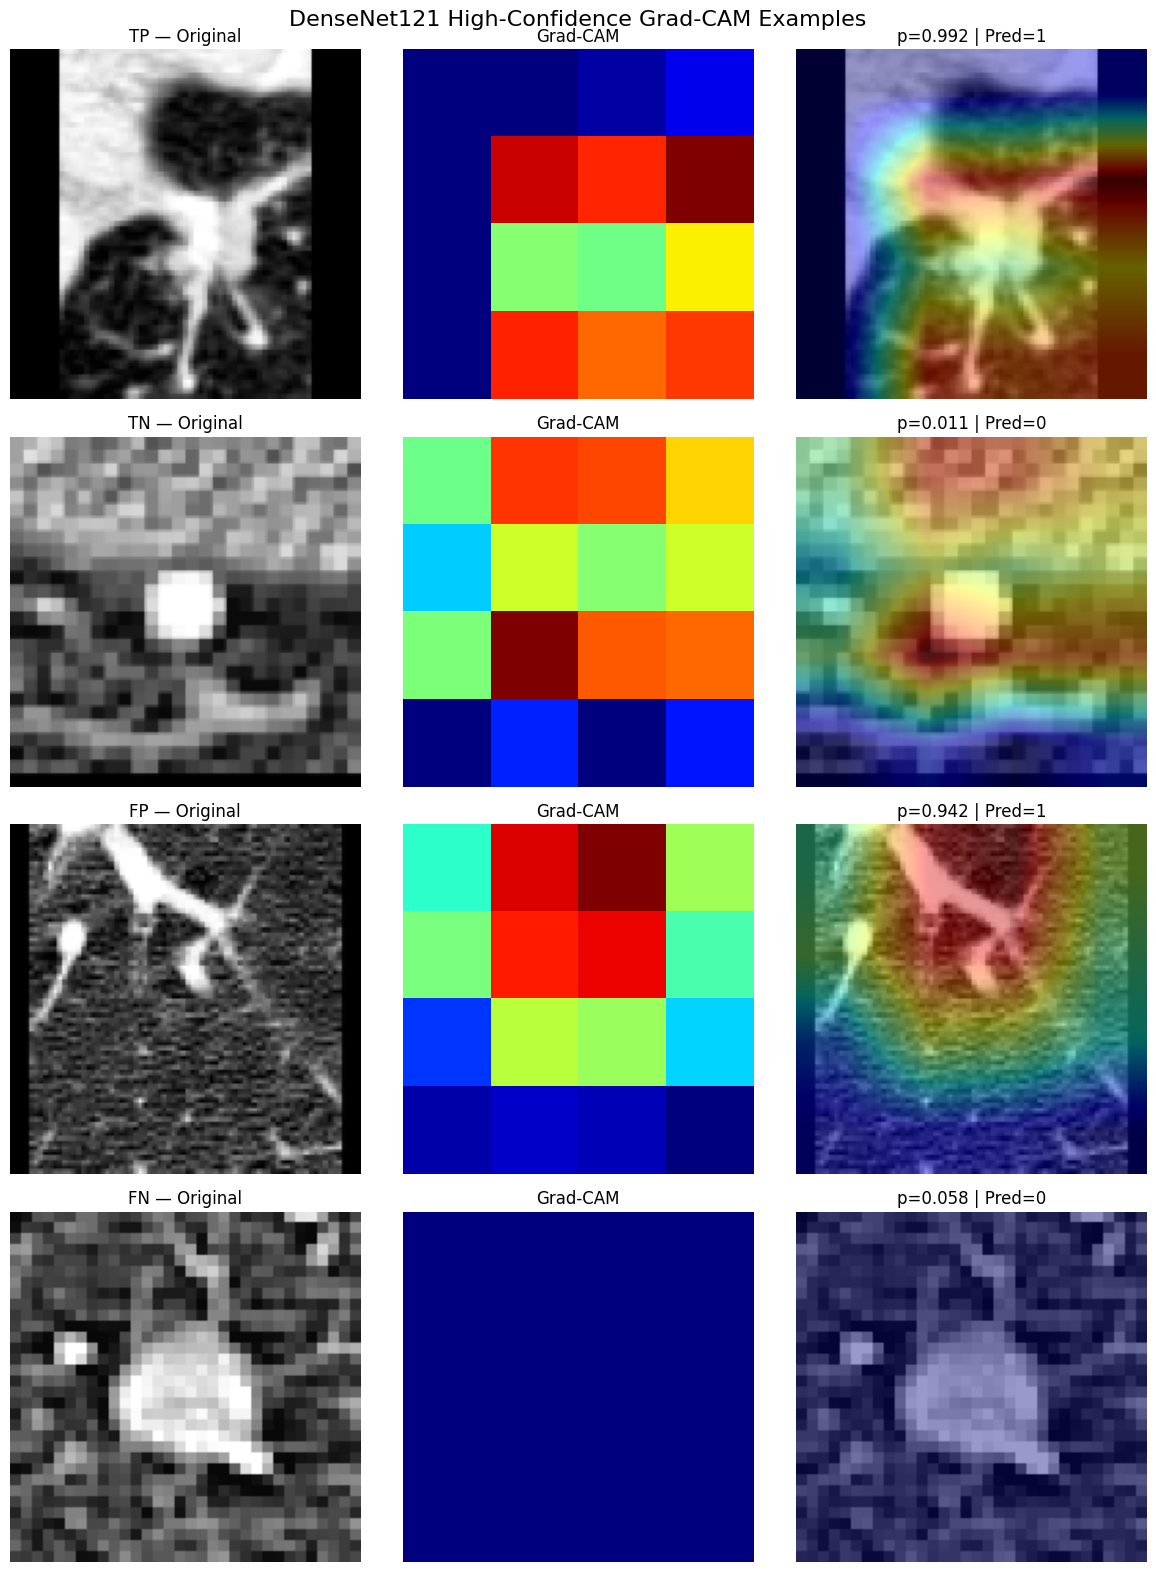

In [163]:
fig, axes = plt.subplots(
    len(
        high_confidence_panel_df
    ),
    3,
    figsize=(
        12,
        4
        * len(
            high_confidence_panel_df
        )
    )
)

for row_index, (
    _,
    row
) in enumerate(
    high_confidence_panel_df
    .iterrows()
):

    image = (
        load_image_for_model(
            row[
                "ResolvedImagePath"
            ]
        )
    )

    image_batch = (
        tf.expand_dims(
            image,
            axis=0
        )
    )

    predicted_label = int(
        row[
            "PredictedLabel"
        ]
    )

    heatmap = (
        make_gradcam_heatmap(
            image_batch=image_batch,
            model=densenet_model,
            backbone=densenet_backbone,
            feature_extractor=backbone_feature_extractor,
            target_class=predicted_label
        )
    )

    _, _, overlay = (
        create_gradcam_overlay(
            image,
            heatmap
        )
    )

    axes[
        row_index,
        0
    ].imshow(
        image.numpy()
        .astype(
            np.uint8
        )
    )

    axes[
        row_index,
        0
    ].set_title(
        f"{row['Outcome']} — Original"
    )

    axes[
        row_index,
        1
    ].imshow(
        heatmap,
        cmap="jet"
    )

    axes[
        row_index,
        1
    ].set_title(
        "Grad-CAM"
    )

    axes[
        row_index,
        2
    ].imshow(
        overlay
    )

    axes[
        row_index,
        2
    ].set_title(
        (
            f"p={row['PredictedProbability']:.3f}"
            f" | Pred={int(row['PredictedLabel'])}"
        )
    )

    for column in range(3):

        axes[
            row_index,
            column
        ].axis(
            "off"
        )

plt.suptitle(
    "DenseNet121 High-Confidence Grad-CAM Examples",
    fontsize=16
)

plt.tight_layout()

HIGH_CONFIDENCE_PANEL_PATH = (
    GRADCAM_ROOT
    / "densenet121_gradcam_high_confidence_panel.png"
)

plt.savefig(
    HIGH_CONFIDENCE_PANEL_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##31. Typical-case dissertation panel

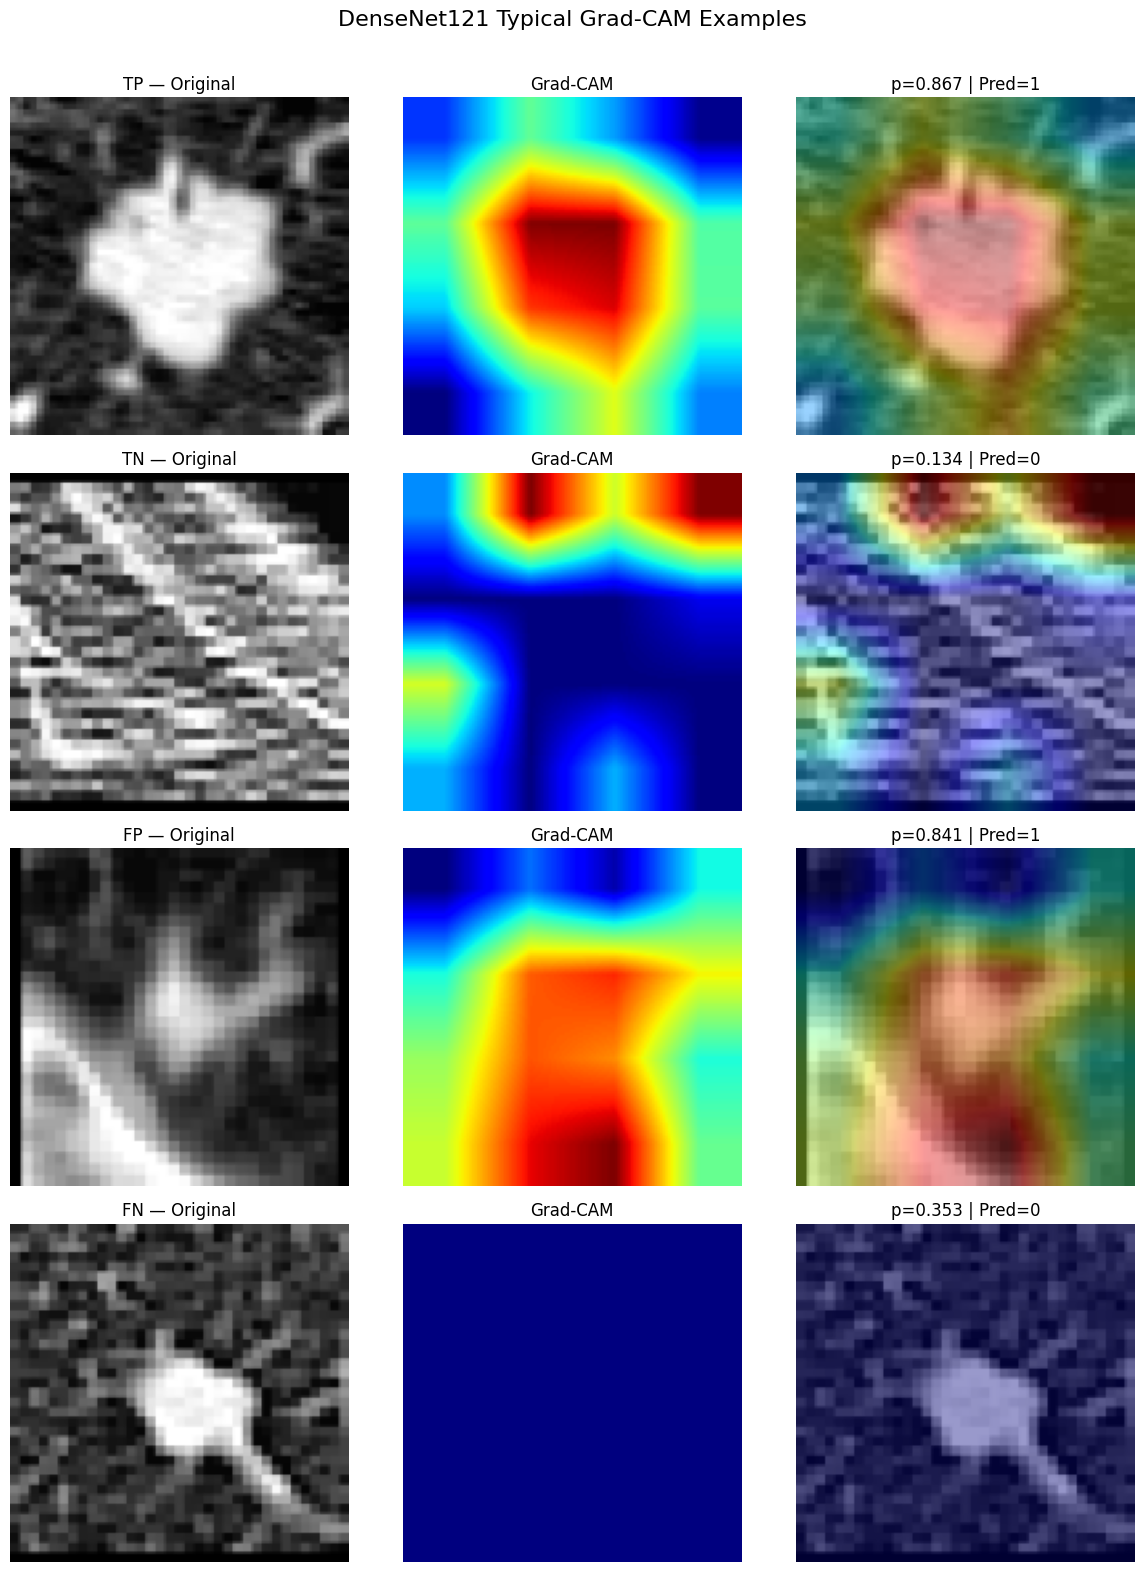

Saved typical-case Grad-CAM panel:
/content/drive/MyDrive/Dissertation/Models/Model_Comparison/GradCAM_DenseNet121/densenet121_gradcam_typical_cases_panel.png
Exists: True


In [169]:
# ============================================================
# Typical-Case Dissertation Panel
# ============================================================

if len(typical_cases_df) == 0:
    raise RuntimeError(
        "No typical cases are available for Grad-CAM plotting."
    )

fig, axes = plt.subplots(
    len(typical_cases_df),
    3,
    figsize=(
        12,
        4 * len(typical_cases_df)
    )
)

# Handle single-row case safely
if len(typical_cases_df) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )

for row_index, (_, row) in enumerate(
    typical_cases_df.iterrows()
):

    # --------------------------------------------------------
    # Load original image
    # --------------------------------------------------------

    image = load_image_for_model(
        row["ResolvedImagePath"]
    )

    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    predicted_label = int(
        row["PredictedLabel"]
    )

    # --------------------------------------------------------
    # Generate class-targeted Grad-CAM
    # --------------------------------------------------------

    heatmap = make_gradcam_heatmap(
        image_batch=image_batch,
        model=densenet_model,
        backbone=densenet_backbone,
        feature_extractor=backbone_feature_extractor,
        target_class=predicted_label
    )

    heatmap_resized, \
    heatmap_rgb, \
    overlay = create_gradcam_overlay(
        image,
        heatmap
    )

    # --------------------------------------------------------
    # Original image
    # --------------------------------------------------------

    axes[
        row_index,
        0
    ].imshow(
        image.numpy().astype(
            np.uint8
        )
    )

    axes[
        row_index,
        0
    ].set_title(
        f"{row['Outcome']} — Original"
    )

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    axes[
        row_index,
        1
    ].imshow(
        heatmap_resized,
        cmap="jet"
    )

    axes[
        row_index,
        1
    ].set_title(
        "Grad-CAM"
    )

    # --------------------------------------------------------
    # Overlay
    # --------------------------------------------------------

    axes[
        row_index,
        2
    ].imshow(
        overlay
    )

    axes[
        row_index,
        2
    ].set_title(
        (
            f"p={row['PredictedProbability']:.3f}"
            f" | Pred={predicted_label}"
        )
    )

    for column in range(3):

        axes[
            row_index,
            column
        ].axis(
            "off"
        )

plt.suptitle(
    "DenseNet121 Typical Grad-CAM Examples",
    fontsize=16
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ]
)

TYPICAL_PANEL_PATH = (
    GRADCAM_ROOT
    / "densenet121_gradcam_typical_cases_panel.png"
)

plt.savefig(
    TYPICAL_PANEL_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "Saved typical-case Grad-CAM panel:"
)

print(
    TYPICAL_PANEL_PATH
)

print(
    "Exists:",
    TYPICAL_PANEL_PATH.exists()
)

##32. Save Grad-CAM configuration

In [170]:
gradcam_configuration = {

    "Architecture":
        "DenseNet121",

    "Checkpoint":
        str(
            MODEL_PATH
        ),

    "ArchitectureSelectionMetric":
        "Validation PR-AUC",

    "ValidationPRAUC":
        float(
            densenet_summary.loc[
                0,
                "Fine-Tuned Validation PR-AUC"
            ]
        ),

    "TestROCAUC":
        float(
            verified_test_roc_auc
        ),

    "TestPRAUC":
        float(
            verified_test_pr_auc
        ),

    "DecisionThreshold":
        float(
            F1_THRESHOLD
        ),

    "DecisionThresholdSource":
        "Validation F1 optimisation",

    "HighRecallThreshold":
        float(
            HIGH_RECALL_THRESHOLD
        ),

    "GradCAMLayer":
        LAST_CONV_LAYER_NAME,

    "GradCAMFeatureShape":
        list(
            sample_heatmap.shape
        ),

    "GradCAMTarget":
        "Predicted class"
}

In [171]:
GRADCAM_CONFIG_PATH = (
    GRADCAM_ROOT
    / "gradcam_configuration.json"
)

with open(
    GRADCAM_CONFIG_PATH,
    "w"
) as file:

    json.dump(
        gradcam_configuration,
        file,
        indent=4
    )

print(
    json.dumps(
        gradcam_configuration,
        indent=4
    )
)

{
    "Architecture": "DenseNet121",
    "Checkpoint": "/content/drive/MyDrive/Dissertation/Models/DenseNet121/Corrected_Run_01/FineTune_Last30/best_model.keras",
    "ArchitectureSelectionMetric": "Validation PR-AUC",
    "ValidationPRAUC": 0.5876770576684937,
    "TestROCAUC": 0.855332902391726,
    "TestPRAUC": 0.5881362975400494,
    "DecisionThreshold": 0.6690409183502197,
    "DecisionThresholdSource": "Validation F1 optimisation",
    "HighRecallThreshold": 0.4456476867198944,
    "GradCAMLayer": "conv5_block16_2_conv",
    "GradCAMFeatureShape": [
        4,
        4
    ],
    "GradCAMTarget": "Predicted class"
}


##33. Final Notebook 14B validations

In [172]:
required_outputs = [

    DENSENET_TEST_PREDICTIONS_PATH,

    GRADCAM_METADATA_PATH,

    OUTCOME_SUMMARY_PATH,

    HIGH_CONFIDENCE_PANEL_PATH,

    TYPICAL_PANEL_PATH,

    GRADCAM_CONFIG_PATH
]

print(
    "=" * 70
)

print(
    "NOTEBOOK 14B FINAL VALIDATION"
)

print(
    "=" * 70
)

for path in required_outputs:

    print(
        f"{path.name:<55}",
        "✓"
        if path.exists()
        else "✗"
    )

print(
    "=" * 70
)

print(
    "Architecture:",
    "DenseNet121"
)

print(
    "Selection metric:",
    "Validation PR-AUC"
)

print(
    "Validation PR-AUC:",
    densenet_summary.loc[
        0,
        "Fine-Tuned Validation PR-AUC"
    ]
)

print(
    "Verified test ROC-AUC:",
    verified_test_roc_auc
)

print(
    "Verified test PR-AUC:",
    verified_test_pr_auc
)

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

print(
    "Heatmap shape:",
    sample_heatmap.shape
)

NOTEBOOK 14B FINAL VALIDATION
densenet121_test_predictions.csv                        ✓
gradcam_metadata.csv                                    ✓
gradcam_outcome_summary.csv                             ✓
densenet121_gradcam_high_confidence_panel.png           ✓
densenet121_gradcam_typical_cases_panel.png             ✓
gradcam_configuration.json                              ✓
Architecture: DenseNet121
Selection metric: Validation PR-AUC
Validation PR-AUC: 0.5876770576684937
Verified test ROC-AUC: 0.855332902391726
Verified test PR-AUC: 0.5881362975400494
Grad-CAM layer: conv5_block16_2_conv
Heatmap shape: (4, 4)


In [168]:
assert all(
    path.exists()
    for path in required_outputs
)

print(
    "\n✓ Notebook 14B completed successfully."
)

AssertionError: 